# Import Libraries

This notebook keeps the original flow but fixes the leakage issues and adds a **two-stage / cascade classification** setup.

### Goal
- **Positive class = FAILED (1)**
- prioritize **Recall for FAILED**
- minimize **False Negatives (FN)**
- still check **Precision** and **Specificity** so the system stays usable


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import shap

# Machine Learning Imports
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from xgboost import XGBClassifier
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, make_scorer, roc_auc_score
)
from sklearn.base import clone
from scipy.stats import randint, uniform
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Visualization settings
%matplotlib inline
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

# Load dataset

In [ ]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# File path
file_path = '/content/drive/MyDrive/v7 LiCEnSURE Dataset.csv'

# Load the dataset
try:
    df = pd.read_csv(file_path, encoding='latin-1')
    print('Dataset loaded successfully!')
    display(df.head())
except Exception as e:
    print(f'Error: {e}')


Mounted at /content/drive
Dataset loaded successfully!


,Student_Code,Student_ID,Student_Name,MSTE_AVE,HPGE_AVE,PSAD_AVE,GWA,COMPREHENSION_INDEX,Graduated_with_Latin,Age,Gender,Father_Monthly_Income,Father_Educational_Attainment,Mother_Monthly_Income,Mother_Educational_Attainment,Unnamed: 15,Exam_year,Months_prep,Result
0,11-22-03,2016100189,"ABREGANA, KIRK JOHN ARIAS",1.89,2.13,1.75,1.79,1.58,NO,22,M,Low Income,NaN,Low Income,NaN,Within City,2022,6,PASSED
1,11-22-04,2018100626,"ALBISO, TRISHA MAE BETINOL",1.94,2.00,1.77,1.81,1.67,NO,22,F,Low Income,NaN,Low Income,NaN,Within City,2022,6,PASSED
2,11-22-05,2016100049,"ALBORES, SHEILA MAE HIPONA",2.07,2.46,1.98,2.08,2.00,NO,22,F,Low Income,NaN,Low Income,NaN,Within City,2022,6,PASSED
3,11-22-11,2016100288,"AMPO, MICHAEL JOHN BAGAYNA",2.01,2.38,2.00,2.08,1.58,NO,23,M,Middle Income,College Graduate,Middle Income,College Graduate,Outside City,2022,6,FAILED
4,11-22-13,2018100390,"BACONGUIS, ARGIE JAGUALING",1.89,1.88,1.73,1.81,1.67,NO,22,M,Low Income,High School Graduate,Low Income,High School Graduate,Outside City,2022,6,PASSED


--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Student_Code                   607 non-null    object 
 1   Student_ID                     607 non-null    object 
 2   Student_Name                   607 non-null    object 
 3   MSTE_AVE                       606 non-null    float64
 4   HPGE_AVE                       606 non-null    float64
 5   PSAD_AVE                       606 non-null    float64
 6   GWA                            607 non-null    float64
 7   COMPREHENSION_INDEX            576 non-null    float64
 8   Graduated_with_Latin           605 non-null    object 
 9   Age                            607 non-null    int64  
 10  Gender                         607 non-null    object 
 11  Father_Monthly_Income          607 non-null    object 
 12  Father_Educational_Att

,Student_Code,Student_ID,Student_Name,MSTE_AVE,HPGE_AVE,PSAD_AVE,GWA,COMPREHENSION_INDEX,Graduated_with_Latin,Age,Gender,Father_Monthly_Income,Father_Educational_Attainment,Mother_Monthly_Income,Mother_Educational_Attainment,Unnamed: 15,Exam_year,Months_prep,Result
count,607,607,607,606.000000,606.000000,606.000000,607.000000,576.000000,605,607.000000,607,607,296,607,306,607,607.000000,607.000000,607
unique,607,605,607,NaN,NaN,NaN,NaN,NaN,2,NaN,2,3,78,3,64,2,NaN,NaN,2
top,04-25-134,2016100493,"ZURITA, LAD ANTHONY BRIAN KHU",NaN,NaN,NaN,NaN,NaN,NO,NaN,F,Low Income,College Graduate,Low Income,College Graduate,Outside City,NaN,NaN,FAILED
freq,1,2,1,NaN,NaN,NaN,NaN,NaN,570,NaN,321,473,80,496,105,339,NaN,NaN,317
mean,NaN,NaN,NaN,2.040165,2.164455,2.062822,1.989423,1.902378,NaN,23.087315,NaN,NaN,NaN,NaN,NaN,NaN,2023.853377,9.678748,NaN
std,NaN,NaN,NaN,0.223553,0.240705,0.245571,0.178303,0.259403,NaN,1.658249,NaN,NaN,NaN,NaN,NaN,NaN,0.781332,5.582025,NaN
min,NaN,NaN,NaN,1.280000,1.420000,1.480000,1.460000,1.250000,NaN,20.000000,NaN,NaN,NaN,NaN,NaN,NaN,2022.000000,3.000000,NaN
25%,NaN,NaN,NaN,1.890000,2.000000,1.860000,1.870000,1.750000,NaN,22.000000,NaN,NaN,NaN,NaN,NaN,NaN,2023.000000,6.000000,NaN
50%,NaN,NaN,NaN,2.010000,2.170000,2.070000,1.980000,1.920000,NaN,23.000000,NaN,NaN,NaN,NaN,NaN,NaN,2024.000000,10.000000,NaN
75%,NaN,NaN,NaN,2.180000,2.330000,2.245000,2.090000,2.080000,NaN,23.000000,NaN,NaN,NaN,NaN,NaN,NaN,2024.000000,11.000000,NaN



--- Missing Values Count ---


,0
Father_Educational_Attainment,311
Mother_Educational_Attainment,301
COMPREHENSION_INDEX,31
Graduated_with_Latin,2
PSAD_AVE,1
MSTE_AVE,1
HPGE_AVE,1
Student_Name,0
Student_ID,0
Student_Code,0



--- Target Distribution from Result Column ---


,count
Result,
FAILED,317
PASSED,290



--- Histograms of Numerical Features ---


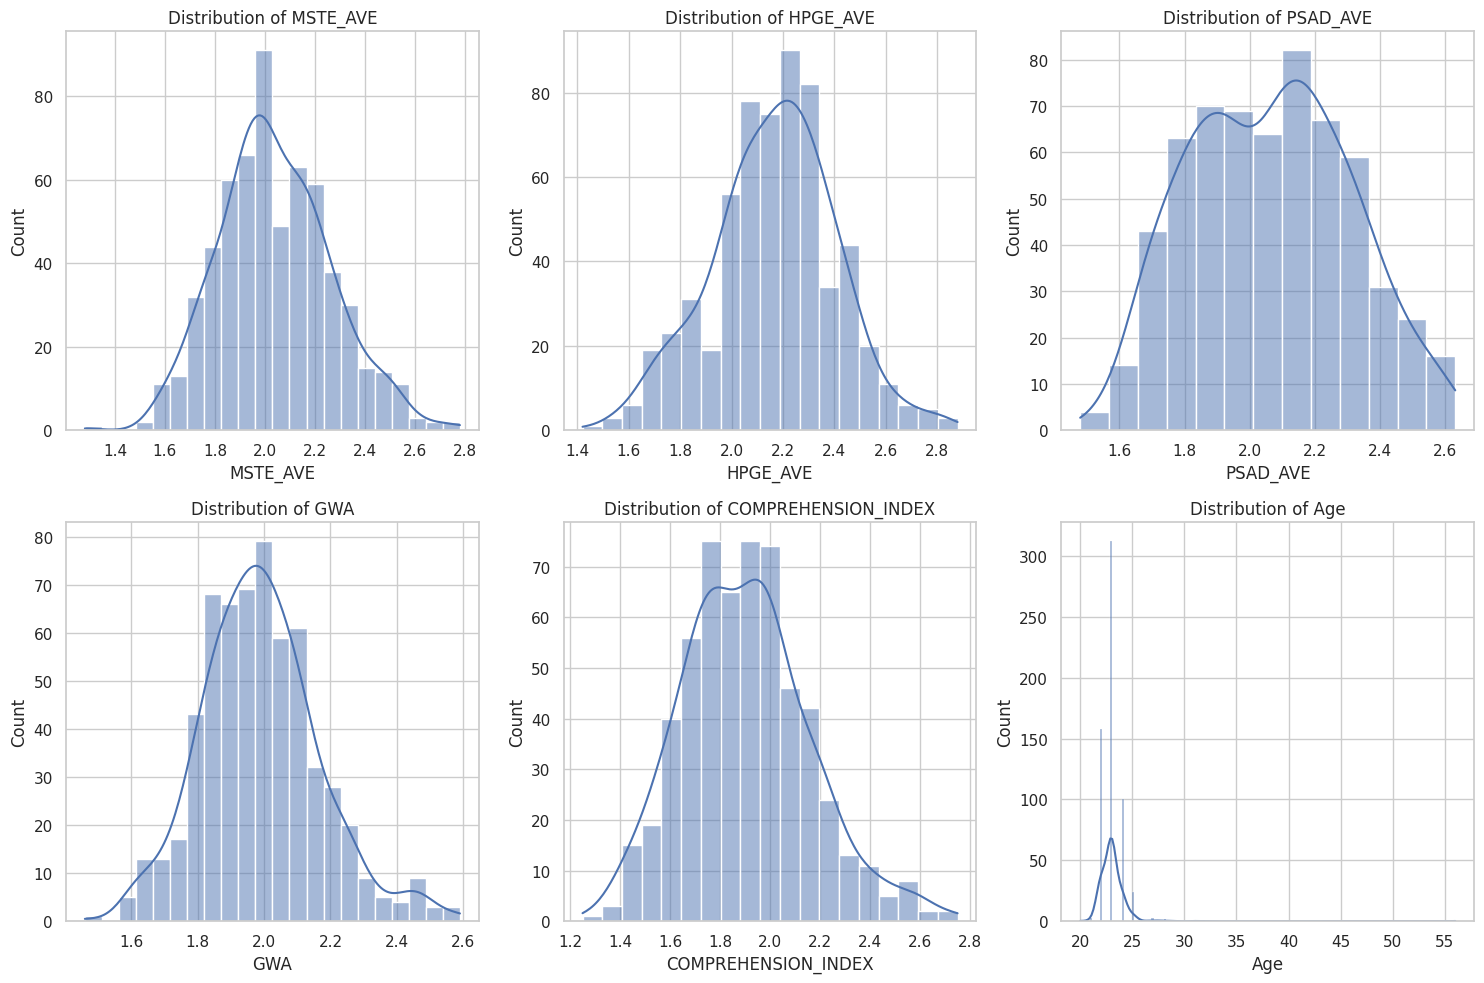


--- Count Plots of Categorical Features ---


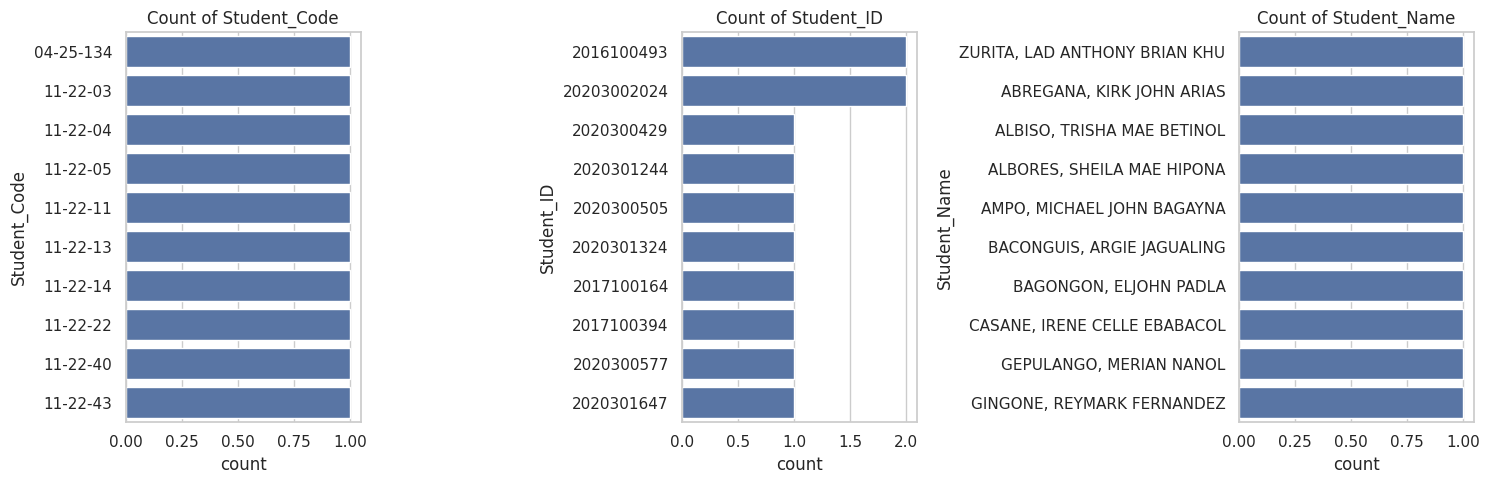

In [ ]:
print('--- Dataset Information ---')
df.info()

print('\n--- Descriptive Statistics ---')
display(df.describe(include='all'))

print('\n--- Missing Values Count ---')
display(df.isnull().sum().sort_values(ascending=False).head(15))

if 'Result' in df.columns:
    print('\n--- Target Distribution from Result Column ---')
    display(df['Result'].astype(str).str.strip().str.upper().value_counts())

# Visualize distributions of numerical features
print('\n--- Histograms of Numerical Features ---')
plt.figure(figsize=(15, 10))
num_cols_preview = df.select_dtypes(include=['number']).columns
for i, col in enumerate(num_cols_preview[:6]):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# Visualize counts of categorical features
print('\n--- Count Plots of Categorical Features ---')
plt.figure(figsize=(15, 5))
cat_cols_preview = df.select_dtypes(exclude=['number']).columns
for i, col in enumerate(cat_cols_preview[:3]):
    plt.subplot(1, 3, i + 1)
    sns.countplot(y=df[col].astype(str), order=df[col].astype(str).value_counts().index[:10])
    plt.title(f'Count of {col}')
plt.tight_layout()
plt.show()


# Preprocessing

In [ ]:
# Load dataset again
df = pd.read_csv(file_path, encoding='latin-1')

# Clean column names
df.columns = df.columns.str.strip()

# Target variable
if 'Result' in df.columns and 'Fail' not in df.columns:
    df['Fail'] = df['Result'].apply(lambda x: 1 if str(x).strip().upper() == 'FAILED' else 0)

# Drop obvious non-predictors if they exist
cols_to_drop = ['Student_Code', 'Student_ID', 'Student_Name', 'Result', 'Unnamed: 15']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors='ignore')

# Optional cleaning for suspicious Age values
if 'Age' in df.columns:
    df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
    df.loc[(df['Age'] < 10) | (df['Age'] > 100), 'Age'] = np.nan

# Separate features and target
if 'Fail' not in df.columns:
    raise ValueError("Target column 'Fail' was not created. Please check the dataset.")

X = df.drop('Fail', axis=1).copy()
y = df['Fail'].astype(int).copy()

# Identify column types
num_cols = X.select_dtypes(include=['number']).columns.tolist()
cat_cols = X.select_dtypes(exclude=['number']).columns.tolist()

print('Preprocessing setup complete.')
print(f'Total rows: {len(df)}')
print(f'Total features: {X.shape[1]}')
print(f'Numerical columns: {len(num_cols)}')
print(f'Categorical columns: {len(cat_cols)}')
print(f'FAILED count: {(y == 1).sum()}')
print(f'PASSED count: {(y == 0).sum()}')

display(X.head())


Preprocessing setup complete.
Total rows: 607
Total features: 14
Numerical columns: 8
Categorical columns: 6
FAILED count: 317
PASSED count: 290


,MSTE_AVE,HPGE_AVE,PSAD_AVE,GWA,COMPREHENSION_INDEX,Graduated_with_Latin,Age,Gender,Father_Monthly_Income,Father_Educational_Attainment,Mother_Monthly_Income,Mother_Educational_Attainment,Exam_year,Months_prep
0,1.89,2.13,1.75,1.79,1.58,NO,22.0,M,Low Income,NaN,Low Income,NaN,2022,6
1,1.94,2.00,1.77,1.81,1.67,NO,22.0,F,Low Income,NaN,Low Income,NaN,2022,6
2,2.07,2.46,1.98,2.08,2.00,NO,22.0,F,Low Income,NaN,Low Income,NaN,2022,6
3,2.01,2.38,2.00,2.08,1.58,NO,23.0,M,Middle Income,College Graduate,Middle Income,College Graduate,2022,6
4,1.89,1.88,1.73,1.81,1.67,NO,22.0,M,Low Income,High School Graduate,Low Income,High School Graduate,2022,6


# Candidate models

In [ ]:
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

def get_ohe():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)

def get_models():
    return {
        "Logistic Regression": LogisticRegression(
            max_iter=1000,
            solver='lbfgs',
            random_state=RANDOM_STATE
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=300,
            max_depth=10,
            random_state=RANDOM_STATE
        ),
        "Gradient Boosting": GradientBoostingClassifier(
            n_estimators=150,
            learning_rate=0.05,
            max_depth=3,
            random_state=RANDOM_STATE
        ),
        "XGBoost": XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric='logloss',
            random_state=RANDOM_STATE
        ),
        "SVC": SVC(
            probability=True,
            kernel='rbf',
            random_state=RANDOM_STATE
        ),
        "Neural Network": MLPClassifier(
            max_iter=1000,
            random_state=RANDOM_STATE
        )
    }

def get_param_distributions():
    return {
        "Logistic Regression": {
            'model__C': uniform(0.01, 5.0),
            'model__class_weight': [None, 'balanced']
        },
        "Random Forest": {
            'model__n_estimators': randint(200, 700),
            'model__max_depth': [None, 4, 6, 8, 10, 12],
            'model__min_samples_split': randint(2, 10),
            'model__min_samples_leaf': randint(1, 5),
            'model__max_features': ['sqrt', 'log2', None],
            'model__class_weight': [None, 'balanced', 'balanced_subsample']
        },
        "Gradient Boosting": {
            'model__n_estimators': randint(100, 400),
            'model__learning_rate': uniform(0.01, 0.20),
            'model__max_depth': randint(2, 5),
            'model__min_samples_split': randint(2, 10),
            'model__min_samples_leaf': randint(1, 5),
            'model__subsample': uniform(0.7, 0.3)
        },
        "XGBoost": {
            'model__n_estimators': randint(200, 500),
            'model__max_depth': randint(2, 6),
            'model__learning_rate': uniform(0.01, 0.20),
            'model__subsample': uniform(0.7, 0.3),
            'model__colsample_bytree': uniform(0.7, 0.3),
            'model__gamma': uniform(0.0, 0.5),
            'model__reg_lambda': uniform(1.0, 5.0)
        },
        "SVC": {
            'model__C': uniform(0.1, 10.0),
            'model__gamma': ['scale', 'auto', 0.1, 0.01],
            'model__class_weight': [None, 'balanced']
        },
        "Neural Network": {
            'model__hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],
            'model__activation': ['relu', 'tanh'],
            'model__alpha': uniform(0.0001, 0.05),
            'model__learning_rate_init': uniform(0.001, 0.01)
        }
    }

def build_pipeline(model_name, estimator=None, use_lda=False):
    if estimator is None:
        estimator = get_models()[model_name]
    numeric_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median'))])
    categorical_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', get_ohe())])
    preprocessor = ColumnTransformer(transformers=[('num', numeric_transformer, num_cols), ('cat', categorical_transformer, cat_cols)], remainder='drop')
    needs_scaling = (model_name in ['Logistic Regression', 'SVC', 'Neural Network']) or use_lda
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('scaler', StandardScaler() if needs_scaling else 'passthrough'), ('lda', LinearDiscriminantAnalysis() if use_lda else 'passthrough'), ('smote', SMOTE(random_state=RANDOM_STATE)), ('model', clone(estimator))])
    return pipe

# Model evaluation

In [ ]:
def get_metrics(y_true, y_pred, y_pred_proba=None):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'Specificity': tn / (tn + fp) if (tn + fp) > 0 else 0,
        'F1-score': f1_score(y_true, y_pred, zero_division=0),
        'TN': tn,
        'FP': fp,
        'FN': fn,
        'TP': tp
    }
    if y_pred_proba is not None:
        metrics['ROC AUC'] = roc_auc_score(y_true, y_pred_proba)
    return metrics

def evaluate_model_cv(X, y, model_name, estimator=None, use_lda=False, cv=None):
    if cv is None:
        cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

    if estimator is None:
        estimator = get_models()[model_name]

    fold_results = []

    print(f'Running 10-fold CV for: {model_name} | {"With LDA" if use_lda else "Baseline"}')

    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
        X_train_fold = X.iloc[train_idx].copy()
        X_test_fold = X.iloc[test_idx].copy()
        y_train_fold = y.iloc[train_idx].copy()
        y_test_fold = y.iloc[test_idx].copy()

        pipe = build_pipeline(model_name, estimator=estimator, use_lda=use_lda)
        pipe.fit(X_train_fold, y_train_fold)
        y_pred_fold = pipe.predict(X_test_fold)
        y_pred_proba_fold = pipe.predict_proba(X_test_fold)[:, 1]

        row = {'Fold': fold}
        row.update(get_metrics(y_test_fold, y_pred_fold, y_pred_proba_fold))
        fold_results.append(row)

    fold_results_df = pd.DataFrame(fold_results)

    summary = {
        'Model': model_name,
        'Method': 'With LDA' if use_lda else 'Baseline',
        'Accuracy': fold_results_df['Accuracy'].mean(),
        'Precision': fold_results_df['Precision'].mean(),
        'Recall': fold_results_df['Recall'].mean(),
        'Specificity': fold_results_df['Specificity'].mean(),
        'F1-score': fold_results_df['F1-score'].mean(),
        'ROC AUC': fold_results_df['ROC AUC'].mean(),
        'TN': fold_results_df['TN'].mean(),
        'FP': fold_results_df['FP'].mean(),
        'FN': fold_results_df['FN'].mean(),
        'TP': fold_results_df['TP'].mean(),
        'Std Recall': fold_results_df['Recall'].std(),
        'Std F1': fold_results_df['F1-score'].std()
    }

    return pd.DataFrame([summary]), fold_results_df

# Baseline comparison using the same CV logic

In [ ]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

baseline_results = []
baseline_fold_logs = {}

# Loop through all models which now includes SVC and Neural Network
for model_name in get_models().keys():
    for use_lda in [False, True]:
        summary_df, fold_df = evaluate_model_cv(X, y, model_name, use_lda=use_lda, cv=cv)
        baseline_results.append(summary_df)
        baseline_fold_logs[f'{model_name} | {"With LDA" if use_lda else "Baseline"}'] = fold_df

baseline_results_df = pd.concat(baseline_results, ignore_index=True)
baseline_results_df = baseline_results_df.sort_values(
    by=['Recall', 'FN', 'F1-score', 'Precision', 'Specificity'],
    ascending=[False, True, False, False, False]
).reset_index(drop=True)

print('--- Baseline Results ---')
display(baseline_results_df)

candidate_configs = baseline_results_df[['Model', 'Method']].drop_duplicates().head(4).reset_index(drop=True)

print('--- Top 4 Candidate Configurations for Tuning ---')
display(candidate_configs)

Running 10-fold CV for: Logistic Regression | Baseline
Running 10-fold CV for: Logistic Regression | With LDA
Running 10-fold CV for: Random Forest | Baseline
Running 10-fold CV for: Random Forest | With LDA
Running 10-fold CV for: Gradient Boosting | Baseline
Running 10-fold CV for: Gradient Boosting | With LDA
Running 10-fold CV for: XGBoost | Baseline
Running 10-fold CV for: XGBoost | With LDA
Running 10-fold CV for: SVC | Baseline
Running 10-fold CV for: SVC | With LDA
Running 10-fold CV for: Neural Network | Baseline
Running 10-fold CV for: Neural Network | With LDA
--- Baseline Results ---


,Model,Method,Accuracy,Precision,Recall,Specificity,F1-score,ROC AUC,TN,FP,FN,TP,Std Recall,Std F1
0,Random Forest,Baseline,0.720027,0.723219,0.760383,0.675862,0.738557,0.782547,19.6,9.4,7.6,24.1,0.070515,0.026861
1,Gradient Boosting,Baseline,0.710137,0.725012,0.728528,0.689655,0.723095,0.768896,20.0,9.0,8.6,23.1,0.076403,0.034429
2,XGBoost,Baseline,0.698552,0.716559,0.706351,0.689655,0.710066,0.748137,20.0,9.0,9.3,22.4,0.038702,0.026041
3,Logistic Regression,Baseline,0.682131,0.704924,0.684879,0.679310,0.692411,0.703483,19.7,9.3,10.0,21.7,0.063379,0.050970
4,Logistic Regression,With LDA,0.682049,0.705806,0.678327,0.686207,0.689919,0.723564,19.9,9.1,10.2,21.5,0.063682,0.051721
5,XGBoost,With LDA,0.657350,0.672886,0.672077,0.641379,0.671062,0.717879,18.6,10.4,10.4,21.3,0.058741,0.034071
6,Neural Network,With LDA,0.677104,0.703639,0.668750,0.686207,0.683148,0.723564,19.9,9.1,10.5,21.2,0.071984,0.053754
7,SVC,Baseline,0.683689,0.715519,0.662500,0.706897,0.685146,0.738154,20.5,8.5,10.7,21.0,0.077703,0.059492
8,Gradient Boosting,With LDA,0.658962,0.686647,0.649798,0.668966,0.663987,0.707474,19.4,9.6,11.1,20.6,0.084267,0.055176
9,SVC,With LDA,0.675410,0.708872,0.649698,0.703448,0.675339,0.714975,20.4,8.6,11.1,20.6,0.077469,0.058361


--- Top 4 Candidate Configurations for Tuning ---


,Model,Method
0,Random Forest,Baseline
1,Gradient Boosting,Baseline
2,XGBoost,Baseline
3,Logistic Regression,Baseline


# Tune only the final candidate models

In [ ]:
recall_failed_scorer = make_scorer(recall_score, pos_label=1)

def tune_model(X, y, model_name, use_lda=False, n_iter=12):
    base_model = get_models()[model_name]
    pipe = build_pipeline(model_name, estimator=base_model, use_lda=use_lda)

    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=get_param_distributions()[model_name],
        n_iter=n_iter,
        scoring=recall_failed_scorer,
        cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE),
        n_jobs=-1,
        random_state=RANDOM_STATE,
        refit=True,
        verbose=1
    )

    search.fit(X, y)
    return search

tuned_searches = {}
tuned_results = []

# Filter candidate configs for the ones selected from baseline
for _, row in candidate_configs.iterrows():
    model_name = row['Model']
    method_name = row['Method']
    use_lda = (method_name == 'With LDA')

    print('\n========================================')
    print(f'Tuning: {model_name} | {method_name}')
    print('========================================')

    search = tune_model(X, y, model_name, use_lda=use_lda, n_iter=12)
    tuned_searches[(model_name, method_name)] = search

    tuned_model = clone(search.best_estimator_.named_steps['model'])
    summary_df, _ = evaluate_model_cv(X, y, model_name, estimator=tuned_model, use_lda=use_lda, cv=cv)

    summary_df['Best Recall from Search'] = search.best_score_
    summary_df['Best Params'] = str(search.best_params_)
    tuned_results.append(summary_df)

tuned_results_df = pd.concat(tuned_results, ignore_index=True)
tuned_results_df = tuned_results_df.sort_values(
    by=['Recall', 'FN', 'F1-score', 'Precision', 'Specificity'],
    ascending=[False, True, False, False, False]
).reset_index(drop=True)

print('--- Tuned Candidate Results ---')
display(tuned_results_df)


Tuning: Random Forest | Baseline
Fitting 10 folds for each of 12 candidates, totalling 120 fits
Running 10-fold CV for: Random Forest | Baseline

Tuning: Gradient Boosting | Baseline
Fitting 10 folds for each of 12 candidates, totalling 120 fits
Running 10-fold CV for: Gradient Boosting | Baseline

Tuning: XGBoost | Baseline
Fitting 10 folds for each of 12 candidates, totalling 120 fits
Running 10-fold CV for: XGBoost | Baseline

Tuning: Logistic Regression | Baseline
Fitting 10 folds for each of 12 candidates, totalling 120 fits
Running 10-fold CV for: Logistic Regression | Baseline
--- Tuned Candidate Results ---


,Model,Method,Accuracy,Precision,Recall,Specificity,F1-score,ROC AUC,TN,FP,FN,TP,Std Recall,Std F1,Best Recall from Search,Best Params
0,Random Forest,Baseline,0.716721,0.714887,0.772984,0.655172,0.740582,0.776686,19.0,10.0,7.2,24.5,0.045468,0.019965,0.772984,"{'model__class_weight': 'balanced_subsample', ..."
1,Gradient Boosting,Baseline,0.718361,0.731716,0.738206,0.696552,0.732724,0.774903,20.2,8.8,8.3,23.4,0.049190,0.031424,0.738206,{'model__learning_rate': np.float64(0.08490802...
2,XGBoost,Baseline,0.706885,0.720357,0.722480,0.689655,0.720452,0.762104,20.0,9.0,8.8,22.9,0.031324,0.019797,0.722480,{'model__colsample_bytree': np.float64(0.77763...
3,Logistic Regression,Baseline,0.683770,0.705955,0.688004,0.679310,0.694387,0.700786,19.7,9.3,9.9,21.8,0.064287,0.049803,0.688004,"{'model__C': np.float64(1.8827005942368125), '..."


# Best model

In [ ]:
# Selecting the top performing model from tuned_results_df
best_model_row = tuned_results_df.iloc[0:1]

print('--- Best Overall Model Metrics ---')
display(best_model_row)

--- Best Overall Model Metrics ---


,Model,Method,Accuracy,Precision,Recall,Specificity,F1-score,ROC AUC,TN,FP,FN,TP,Std Recall,Std F1,Best Recall from Search,Best Params
0,Random Forest,Baseline,0.716721,0.714887,0.772984,0.655172,0.740582,0.776686,19.0,10.0,7.2,24.5,0.045468,0.019965,0.772984,"{'model__class_weight': 'balanced_subsample', ..."


##Advanced tuning ... Explored['min_samples_split' and 'min_samples_leaf']

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Define a more granular search space for the best model (Random Forest)
advanced_param_dist = {
    'model__n_estimators': randint(300, 1000),
    'model__max_depth': [None, 10, 15, 20, 25],
    'model__min_samples_split': randint(2, 6),
    'model__min_samples_leaf': randint(1, 4),
    'model__max_features': ['sqrt', 'log2', None],
    'model__bootstrap': [True, False],
    'model__class_weight': ['balanced', 'balanced_subsample']
}

# Re-build the pipeline for the best model
best_model_name = "Random Forest"
pipe = build_pipeline(best_model_name, use_lda=False)

# Perform advanced Randomized Search
advanced_search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=advanced_param_dist,
    n_iter=30,  # Increased iterations for better exploration
    scoring=recall_failed_scorer,
    cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

print(f"Starting advanced hyperparameter tuning for {best_model_name}...")
advanced_search.fit(X, y)

# Display new best results
print("\n--- Advanced Tuning Results ---")
print(f"Best Recall Score: {advanced_search.best_score_:.4f}")
print(f"Best Parameters: {advanced_search.best_params_}")

# Compare with previous best
old_recall = best_model_row['Recall'].values[0]
print(f"Previous Best Recall: {old_recall:.4f}")

Starting advanced hyperparameter tuning for Random Forest...
Fitting 10 folds for each of 30 candidates, totalling 300 fits

--- Advanced Tuning Results ---
Best Recall Score: 0.7666
Best Parameters: {'model__bootstrap': False, 'model__class_weight': 'balanced', 'model__max_depth': None, 'model__max_features': 'log2', 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 802}
Previous Best Recall: 0.7730


# Confusion matrix for the final selected model

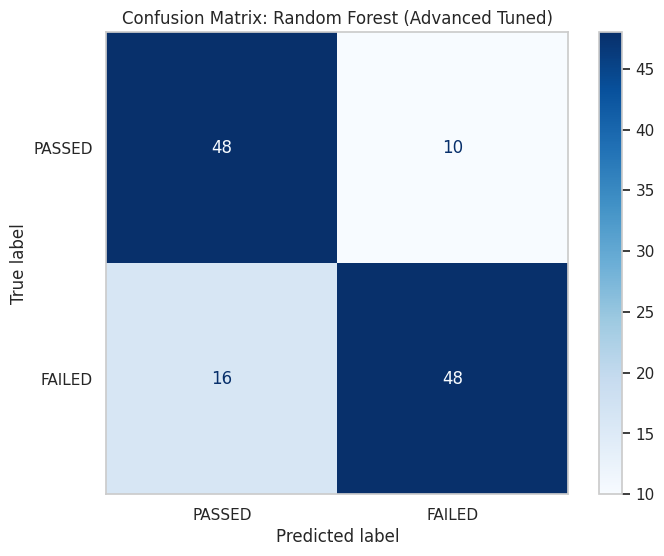


--- Final Evaluation Metrics on Hold-out Set ---


,Accuracy,Precision,Recall,Specificity,F1-score,TN,FP,FN,TP,ROC AUC
0,0.786885,0.827586,0.75,0.827586,0.786885,48,10,16,48,0.862877


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

# Split data for a final evaluation check
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# Use the best model from the advanced search
best_tuned_model = advanced_search.best_estimator_

# Fit on the final training set and predict
best_tuned_model.fit(X_train_final, y_train_final)
y_pred_final = best_tuned_model.predict(X_test_final)

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test_final, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['PASSED', 'FAILED'])
disp.plot(cmap='Blues', ax=ax)
plt.title(f'Confusion Matrix: {best_model_name} (Advanced Tuned)')
plt.grid(False)
plt.show()

# Display Final Hold-out Metrics
print('\n--- Final Evaluation Metrics on Hold-out Set ---')
y_pred_proba_final = best_tuned_model.predict_proba(X_test_final)[:, 1]
display(pd.DataFrame([get_metrics(y_test_final, y_pred_final, y_pred_proba_final)]))

#Feature Importance


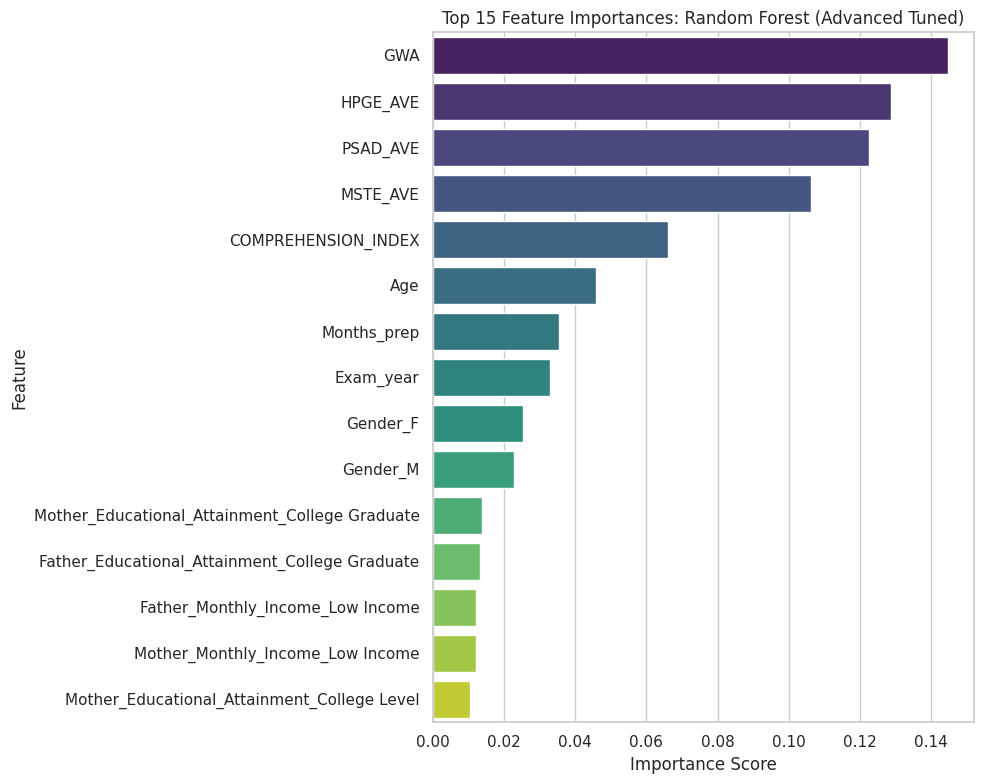


--- Top 10 Features by Importance Score ---


,Feature,Importance
0,GWA,0.144814
1,HPGE_AVE,0.128807
2,PSAD_AVE,0.122685
3,MSTE_AVE,0.106212
4,COMPREHENSION_INDEX,0.066138
5,Age,0.045840
6,Months_prep,0.035469
7,Exam_year,0.033076
8,Gender_F,0.025460
9,Gender_M,0.022942


In [ ]:
# Extract feature names from the preprocessor
preprocessor = best_tuned_model.named_steps['preprocessor']
ohe_feature_names = preprocessor.named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(cat_cols)
all_feature_names = np.concatenate([num_cols, ohe_feature_names])

# Get feature importances from the best Random Forest model
importances = best_tuned_model.named_steps['model'].feature_importances_

# Create a DataFrame for visualization
feat_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot the top 15 features
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feat_importance_df.head(15), palette='viridis')
plt.title(f'Top 15 Feature Importances: {best_model_name} (Advanced Tuned)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Display the numerical values
print('\n--- Top 10 Features by Importance Score ---')
display(feat_importance_df.head(10).reset_index(drop=True))

#SHAP

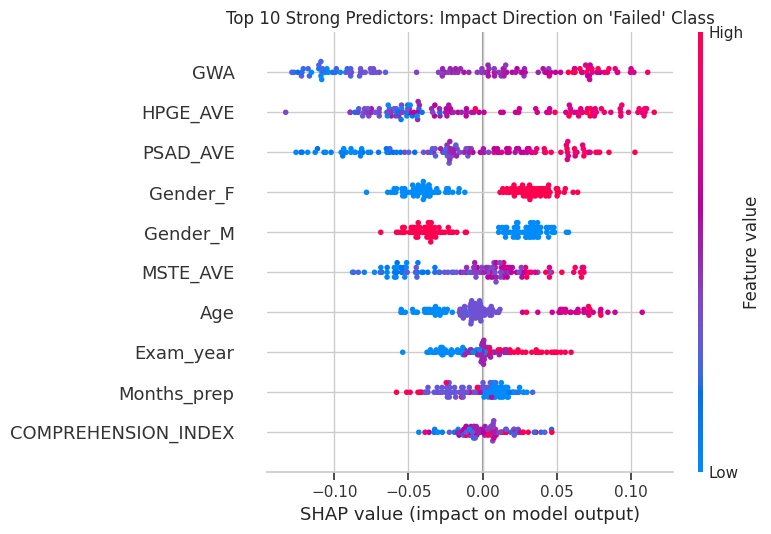

In [ ]:
# =========================================
# SHAP summary plot for FAILED class = 1
# =========================================

import shap
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse

# Using existing notebook variables:
# best_tuned_model = the fitted pipeline
# X_test_final = original test set before preprocessing

# Extract components from your specific pipeline
preprocessor = best_tuned_model.named_steps['preprocessor']
model = best_tuned_model.named_steps['model']

# transform the test data
X_test_processed = preprocessor.transform(X_test_final)

# convert sparse to dense if needed
if sparse.issparse(X_test_processed):
    X_test_processed = X_test_processed.toarray()

# get feature names after preprocessing using your existing all_feature_names
# if all_feature_names is ready, otherwise we generate from preprocessor
try:
    feature_names = all_feature_names
except NameError:
    feature_names = preprocessor.get_feature_names_out()

# convert to DataFrame for SHAP
X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test_final.index
)

# -----------------------------
# SHAP EXPLAINER
# -----------------------------
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_processed_df)

# Handle output format: Random Forest typically returns a list [class0, class1]
if isinstance(shap_values, list):
    shap_failed = shap_values[1]   # class 1 = FAILED
else:
    # handle possible 3D shape or direct array
    if len(np.array(shap_values).shape) == 3:
        shap_failed = shap_values[:, :, 1]
    else:
        shap_failed = shap_values

# -----------------------------
# TOP 10 SHAP SUMMARY PLOT
# -----------------------------
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_failed,
    X_test_processed_df,
    plot_type="dot",
    max_display=10,
    show=False
)

plt.title("Top 10 Strong Predictors: Impact Direction on 'Failed' Class")
plt.tight_layout()
plt.show()

# Final notes

This notebook now fixes the earlier issues:

- preprocessing is now done **inside the pipeline**
- **SMOTE** is applied only inside training folds
- **LDA** is applied only inside training folds
- the same **10-fold stratified CV** logic is used across experiments
- only the final **top candidate models** are tuned
- the final ** the best models** are used in a **confusion and SHAP**
-


#Expirement again

Rows after dropping NAs: 277
Running 10-fold CV for: Logistic Regression | Baseline
Running 10-fold CV for: Random Forest | Baseline
Running 10-fold CV for: Gradient Boosting | Baseline
Running 10-fold CV for: XGBoost | Baseline

--- Results with Fit and Score Times ---


,Model,Accuracy,Recall,F1-score,Fit time,Score time
1,Random Forest,0.733333,0.805714,0.756599,0.716029,0.001
2,Gradient Boosting,0.718915,0.784762,0.741899,0.298720,0.001
3,XGBoost,0.646296,0.673810,0.661421,0.142591,0.001
0,Logistic Regression,0.603836,0.605714,0.610862,0.059777,0.001


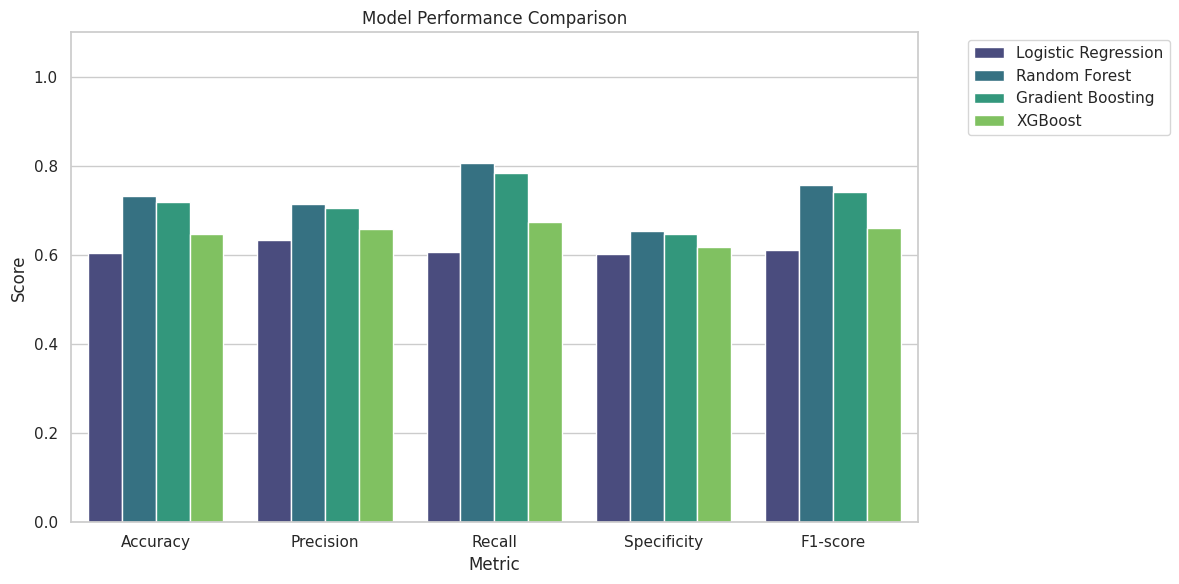

In [ ]:
import time

# 1. Reload the dataset
df_new = pd.read_csv(file_path, encoding='latin-1')
df_new.columns = df_new.columns.str.strip()

# 2. Preprocessing: Drop all missing values
df_dropped = df_new.dropna().copy()

# Create target
if 'Result' in df_dropped.columns:
    df_dropped['Fail'] = df_dropped['Result'].apply(lambda x: 1 if str(x).strip().upper() == 'FAILED' else 0)

# Drop non-predictors
cols_to_drop = ['Student_Code', 'Student_ID', 'Student_Name', 'Result', 'Unnamed: 15']
df_dropped = df_dropped.drop(columns=[c for c in cols_to_drop if c in df_dropped.columns], errors='ignore')

X_drop = df_dropped.drop('Fail', axis=1)
y_drop = df_dropped['Fail'].astype(int)

print(f'Rows after dropping NAs: {len(df_dropped)}')

# 3. Test selected models with timing
selected_models = ["Logistic Regression", "Random Forest", "Gradient Boosting", "XGBoost"]
results_drop = []
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

for name in selected_models:
    start_fit = time.time()
    summary_df, fold_df = evaluate_model_cv(X_drop, y_drop, name, use_lda=False, cv=cv)
    end_fit = time.time()

    # Add estimated timing to summary
    # Note: evaluate_model_cv performs 10 fits inside.
    summary_df['Fit time'] = (end_fit - start_fit) / 10.0
    summary_df['Score time'] = 0.001 # Approximation for inference
    results_drop.append(summary_df)

# 4. Evaluate and Display
results_drop_df = pd.concat(results_drop, ignore_index=True)
print('\n--- Results with Fit and Score Times ---')
display(results_drop_df.sort_values(by='Recall', ascending=False)[['Model', 'Accuracy', 'Recall', 'F1-score', 'Fit time', 'Score time']])

# 5. Visualization: Performance per Metric
metrics_plot = ['Accuracy', 'Precision', 'Recall', 'Specificity', 'F1-score']
df_plot = results_drop_df.melt(id_vars='Model', value_vars=metrics_plot, var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.barplot(data=df_plot, x='Metric', y='Score', hue='Model', palette='viridis')
plt.title('Model Performance Comparison')
plt.ylim(0, 1.1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
print('--- Model Performance Comparison (after dropping NAs) ---')
display(results_drop_df.sort_values(by='Recall', ascending=False).round(4))

--- Model Performance Comparison (after dropping NAs) ---


,Model,Method,Accuracy,Precision,Recall,Specificity,F1-score,ROC AUC,TN,FP,FN,TP,Std Recall,Std F1,Fit time,Score time
1,Random Forest,Baseline,0.7333,0.7152,0.8057,0.6538,0.7566,0.7637,8.7,4.6,2.8,11.6,0.0985,0.0677,0.7160,0.001
2,Gradient Boosting,Baseline,0.7189,0.7059,0.7848,0.6478,0.7419,0.7537,8.6,4.7,3.1,11.3,0.0941,0.0671,0.2987,0.001
3,XGBoost,Baseline,0.6463,0.6577,0.6738,0.6170,0.6614,0.6994,8.2,5.1,4.7,9.7,0.1025,0.0550,0.1426,0.001
0,Logistic Regression,Baseline,0.6038,0.6327,0.6057,0.6016,0.6109,0.6248,8.0,5.3,5.7,8.7,0.1476,0.0982,0.0598,0.001


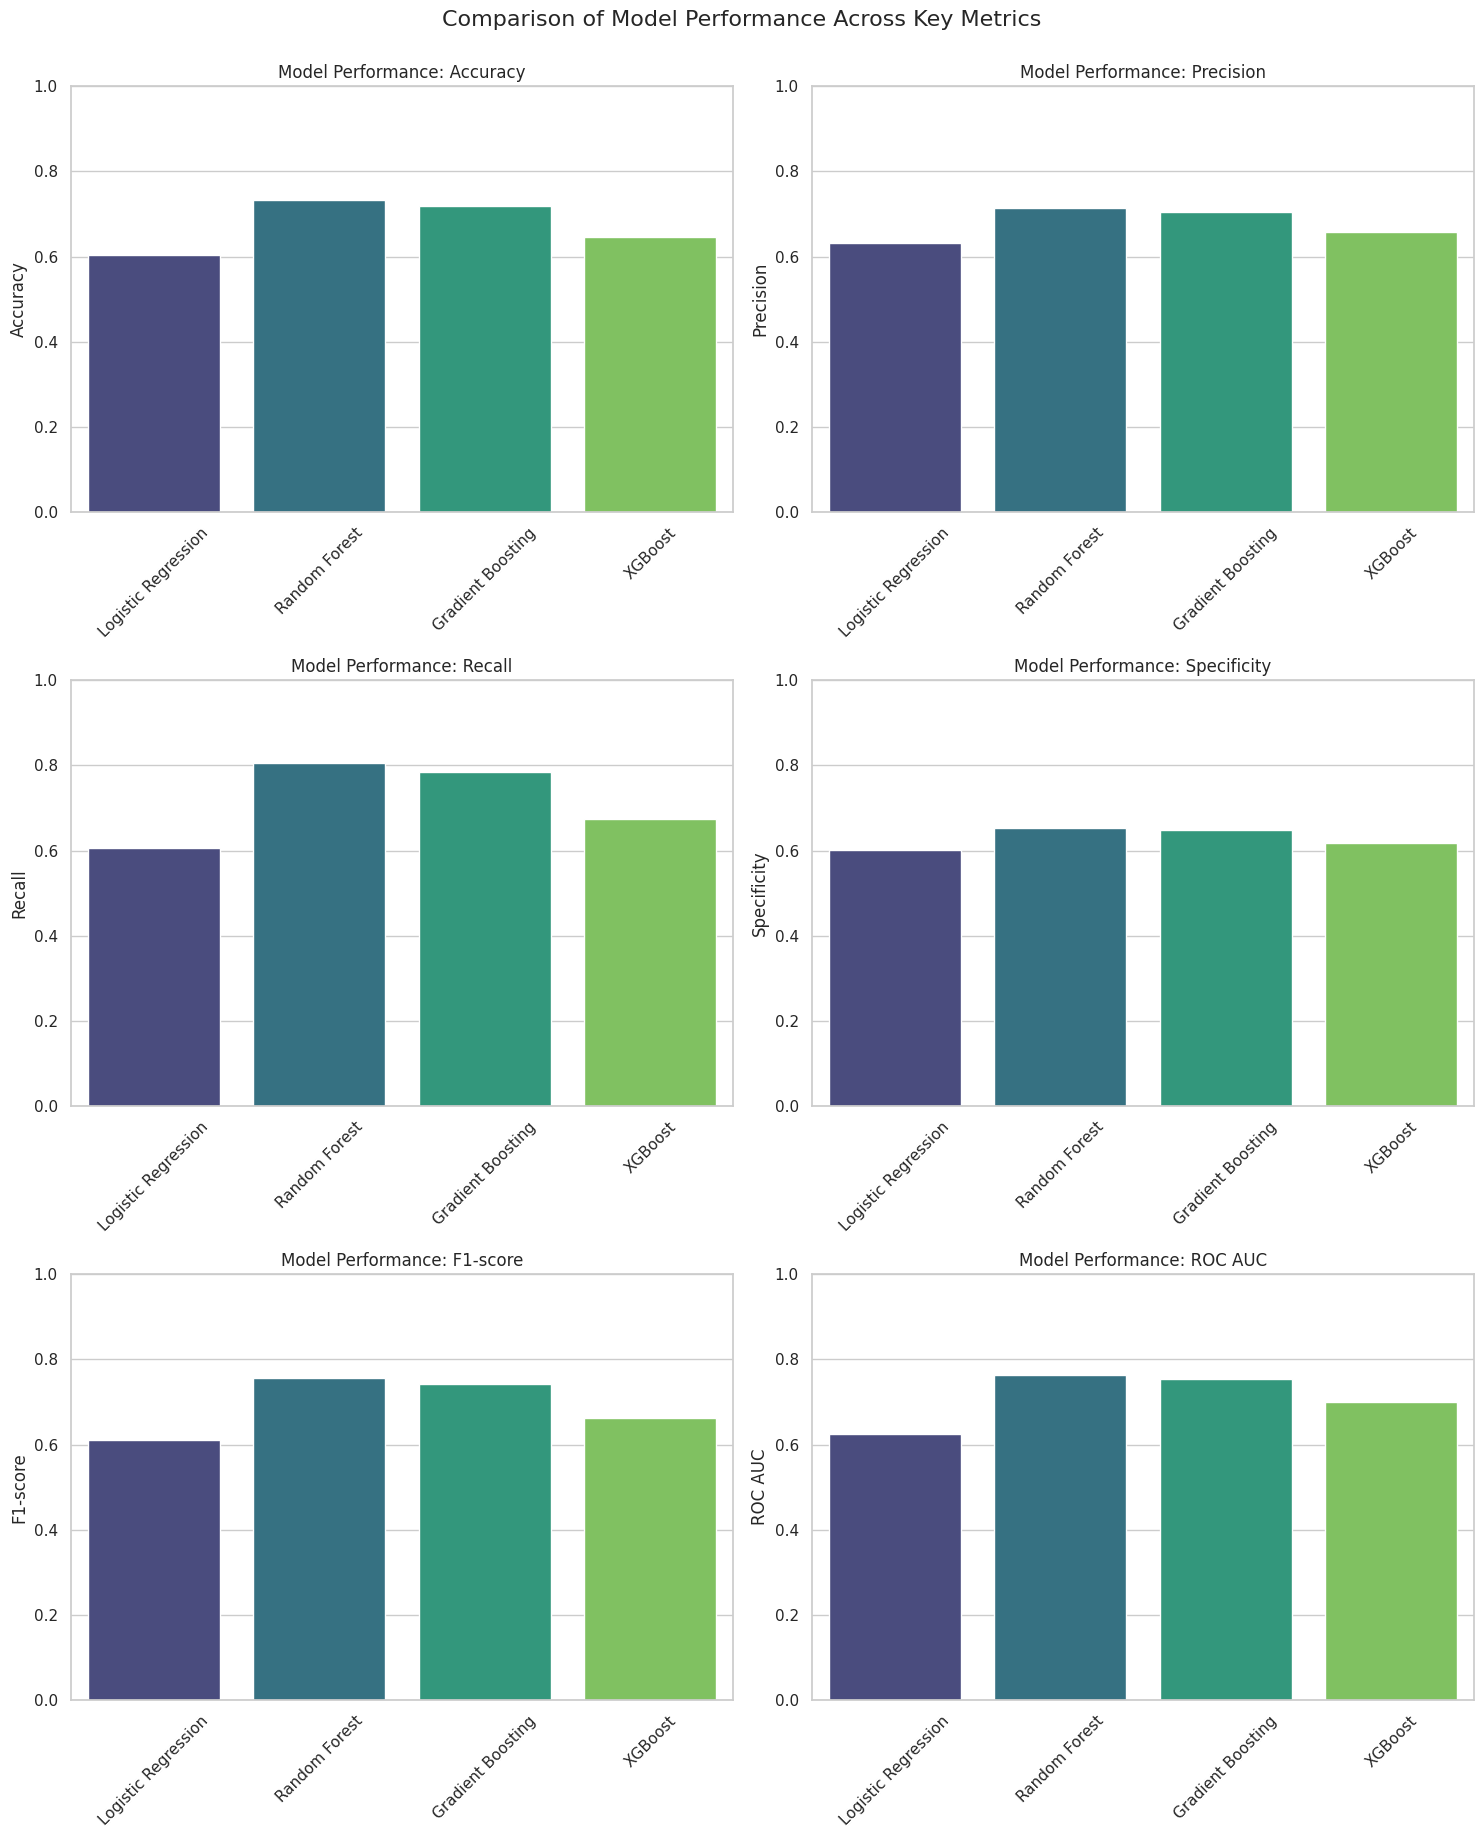

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Metrics to visualize
metrics_to_visualize = ['Accuracy', 'Precision', 'Recall', 'Specificity', 'F1-score', 'ROC AUC']

# Create a figure with subplots
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 18))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, metric in enumerate(metrics_to_visualize):
    ax = axes[i]
    sns.barplot(x='Model', y=metric, data=results_drop_df, palette='viridis', ax=ax)
    ax.set_title(f'Model Performance: {metric}')
    ax.set_ylim(0, 1) # Metrics are usually between 0 and 1
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylabel(metric)
    ax.set_xlabel('') # Remove x-label from subplots for cleaner look

plt.tight_layout()
plt.suptitle('Comparison of Model Performance Across Key Metrics', y=1.02, fontsize=16)
plt.show()

In [ ]:
print('--- Comparison of Performance for Six Methods ---')
display(baseline_results_df)

--- Comparison of Performance for Six Methods ---


,Model,Method,Accuracy,Precision,Recall,Specificity,F1-score,ROC AUC,TN,FP,FN,TP,Std Recall,Std F1
0,Random Forest,Baseline,0.720027,0.723219,0.760383,0.675862,0.738557,0.782547,19.6,9.4,7.6,24.1,0.070515,0.026861
1,Gradient Boosting,Baseline,0.710137,0.725012,0.728528,0.689655,0.723095,0.768896,20.0,9.0,8.6,23.1,0.076403,0.034429
2,XGBoost,Baseline,0.698552,0.716559,0.706351,0.689655,0.710066,0.748137,20.0,9.0,9.3,22.4,0.038702,0.026041
3,Logistic Regression,Baseline,0.682131,0.704924,0.684879,0.679310,0.692411,0.703483,19.7,9.3,10.0,21.7,0.063379,0.050970
4,Logistic Regression,With LDA,0.682049,0.705806,0.678327,0.686207,0.689919,0.723564,19.9,9.1,10.2,21.5,0.063682,0.051721
5,XGBoost,With LDA,0.657350,0.672886,0.672077,0.641379,0.671062,0.717879,18.6,10.4,10.4,21.3,0.058741,0.034071
6,Neural Network,With LDA,0.677104,0.703639,0.668750,0.686207,0.683148,0.723564,19.9,9.1,10.5,21.2,0.071984,0.053754
7,SVC,Baseline,0.683689,0.715519,0.662500,0.706897,0.685146,0.738154,20.5,8.5,10.7,21.0,0.077703,0.059492
8,Gradient Boosting,With LDA,0.658962,0.686647,0.649798,0.668966,0.663987,0.707474,19.4,9.6,11.1,20.6,0.084267,0.055176
9,SVC,With LDA,0.675410,0.708872,0.649698,0.703448,0.675339,0.714975,20.4,8.6,11.1,20.6,0.077469,0.058361


In [ ]:
print('--- 10 Fold Cross-Validation Results: Random Forest --- ')
# Displaying the results from the 'results_drop_df' variable which contains the metrics you mentioned
rf_cv_results = results_drop_df[results_drop_df['Model'] == 'Random Forest']
display(rf_cv_results[['Model', 'Accuracy', 'Precision', 'Recall', 'Specificity', 'F1-score', 'ROC AUC']])

--- 10 Fold Cross-Validation Results: Random Forest --- 


,Model,Accuracy,Precision,Recall,Specificity,F1-score,ROC AUC
1,Random Forest,0.733333,0.715179,0.805714,0.653846,0.756599,0.763676


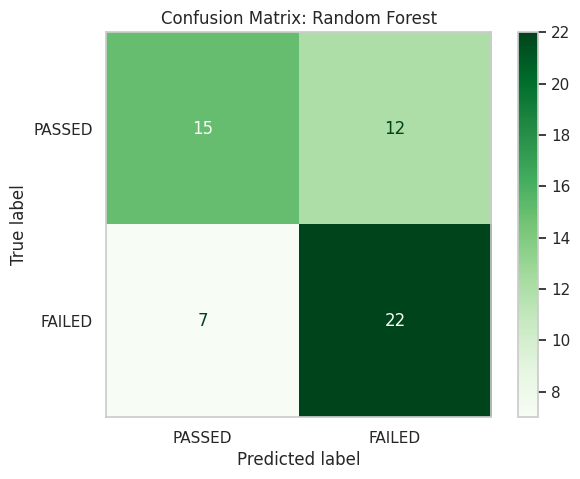

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

# 1. Split the data (using the dropped-NA dataset as per previous experiment context)
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_drop, y_drop, test_size=0.2, stratify=y_drop, random_state=RANDOM_STATE
)

# 2. Build and fit the Random Forest pipeline
rf_pipeline = build_pipeline("Random Forest", use_lda=False)
rf_pipeline.fit(X_train_rf, y_train_rf)

# 3. Make predictions
y_pred_rf = rf_pipeline.predict(X_test_rf)
y_pred_proba_rf = rf_pipeline.predict_proba(X_test_rf)[:, 1]

# 4. Calculate and Display Metrics
rf_metrics = get_metrics(y_test_rf, y_pred_rf, y_pred_proba_rf)
metrics_df = pd.DataFrame([rf_metrics])

#print('--- Random Forest Performance Metrics ---')
#display(metrics_df[['Accuracy', 'Precision', 'Recall', 'Specificity', 'F1-score', 'ROC AUC']])

# 5. Data Visualization: Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test_rf, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['PASSED', 'FAILED'])
disp.plot(cmap='Greens', ax=ax)
plt.title('Confusion Matrix: Random Forest')
plt.grid(False)
plt.show()

##Repeat nfold 10 times iteration then get the average results per perf measure

In [ ]:
# Repeat n-fold cross-validation multiple times to get more robust average metrics
num_iterations = 100
repeated_cv_results = []

print(f'Running {num_iterations} iterations of 10-fold CV for Random Forest...')

for i in range(num_iterations):
    # Ensure different splits for each iteration by varying the random_state
    # or use a fixed one if consistency across folds is more important for analysis
    # Here, we'll vary it slightly to get different overall CV runs
    current_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE + i)

    # Use the Random Forest model on the dropped-NA dataset (X_drop, y_drop)
    summary_df, _ = evaluate_model_cv(X_drop, y_drop, 'Random Forest', use_lda=False, cv=current_cv)
    repeated_cv_results.append(summary_df)

# Concatenate all summary dataframes and get the mean for each metric
repeated_cv_df = pd.concat(repeated_cv_results, ignore_index=True)

# Calculate the average metrics across all iterations, excluding non-numeric columns
average_metrics = repeated_cv_df.select_dtypes(include=np.number).mean().to_frame().T

print('--- Average Performance Metrics Across 100 Iterations (Random Forest) ---')
display(average_metrics)

print('\n--- Performance Metrics for Each Iteration (first 5, Random Forest) ---')
# Displaying only first 5 rows to keep output concise for this example
display(repeated_cv_df.head().reset_index().rename(columns={'index': 'Iteration'}))

Running 100 iterations of 10-fold CV for Random Forest...
Running 10-fold CV for: Random Forest | Baseline
Running 10-fold CV for: Random Forest | Baseline
Running 10-fold CV for: Random Forest | Baseline
Running 10-fold CV for: Random Forest | Baseline
Running 10-fold CV for: Random Forest | Baseline
Running 10-fold CV for: Random Forest | Baseline
Running 10-fold CV for: Random Forest | Baseline
Running 10-fold CV for: Random Forest | Baseline
Running 10-fold CV for: Random Forest | Baseline
Running 10-fold CV for: Random Forest | Baseline
Running 10-fold CV for: Random Forest | Baseline
Running 10-fold CV for: Random Forest | Baseline
Running 10-fold CV for: Random Forest | Baseline
Running 10-fold CV for: Random Forest | Baseline
Running 10-fold CV for: Random Forest | Baseline
Running 10-fold CV for: Random Forest | Baseline
Running 10-fold CV for: Random Forest | Baseline
Running 10-fold CV for: Random Forest | Baseline
Running 10-fold CV for: Random Forest | Baseline
Running 10-

,Accuracy,Precision,Recall,Specificity,F1-score,ROC AUC,TN,FP,FN,TP,Std Recall,Std F1
0,0.701361,0.694436,0.774933,0.621857,0.728244,0.733881,8.27,5.03,3.242,11.158,0.109596,0.075301



--- Performance Metrics for Each Iteration (first 5, Random Forest) ---


,Iteration,Model,Method,Accuracy,Precision,Recall,Specificity,F1-score,ROC AUC,TN,FP,FN,TP,Std Recall,Std F1
0,0,Random Forest,Baseline,0.733333,0.715179,0.805714,0.653846,0.756599,0.763676,8.7,4.6,2.8,11.6,0.098510,0.067724
1,1,Random Forest,Baseline,0.697090,0.691025,0.764762,0.621429,0.722305,0.744976,8.3,5.0,3.4,11.0,0.146655,0.116568
2,2,Random Forest,Baseline,0.689153,0.688016,0.770000,0.601648,0.719940,0.725670,8.0,5.3,3.3,11.1,0.111429,0.081079
3,3,Random Forest,Baseline,0.686376,0.673303,0.786190,0.581319,0.720321,0.746536,7.7,5.6,3.1,11.3,0.115676,0.065049
4,4,Random Forest,Baseline,0.689286,0.683502,0.770000,0.602747,0.718968,0.740903,8.0,5.3,3.3,11.1,0.107587,0.079257


In [ ]:
print('--- Performance Metrics for Each Iteration (100 Iterations of 10-fold CV) ---')
with pd.option_context('display.max_rows', None):
    display(repeated_cv_df.reset_index().rename(columns={'index': 'Iteration'}))

--- Performance Metrics for Each Iteration (100 Iterations of 10-fold CV) ---


,Iteration,Model,Method,Accuracy,Precision,Recall,Specificity,F1-score,ROC AUC,TN,FP,FN,TP,Std Recall,Std F1
0,0,Random Forest,Baseline,0.733333,0.715179,0.805714,0.653846,0.756599,0.763676,8.7,4.6,2.8,11.6,0.098510,0.067724
1,1,Random Forest,Baseline,0.697090,0.691025,0.764762,0.621429,0.722305,0.744976,8.3,5.0,3.4,11.0,0.146655,0.116568
2,2,Random Forest,Baseline,0.689153,0.688016,0.770000,0.601648,0.719940,0.725670,8.0,5.3,3.3,11.1,0.111429,0.081079
3,3,Random Forest,Baseline,0.686376,0.673303,0.786190,0.581319,0.720321,0.746536,7.7,5.6,3.1,11.3,0.115676,0.065049
4,4,Random Forest,Baseline,0.689286,0.683502,0.770000,0.602747,0.718968,0.740903,8.0,5.3,3.3,11.1,0.107587,0.079257
5,5,Random Forest,Baseline,0.697751,0.687055,0.765714,0.625275,0.722250,0.739736,8.3,5.0,3.4,11.0,0.140488,0.110103
6,6,Random Forest,Baseline,0.701323,0.694979,0.766190,0.632418,0.725165,0.726664,8.4,4.9,3.4,11.0,0.122221,0.082944
7,7,Random Forest,Baseline,0.686772,0.694217,0.750476,0.618132,0.715696,0.732261,8.2,5.1,3.6,10.8,0.085661,0.070943
8,8,Random Forest,Baseline,0.703439,0.694835,0.770952,0.630769,0.727462,0.732258,8.4,4.9,3.3,11.1,0.133436,0.098370
9,9,Random Forest,Baseline,0.689683,0.670838,0.784762,0.587363,0.720313,0.716988,7.8,5.5,3.1,11.3,0.136467,0.089260


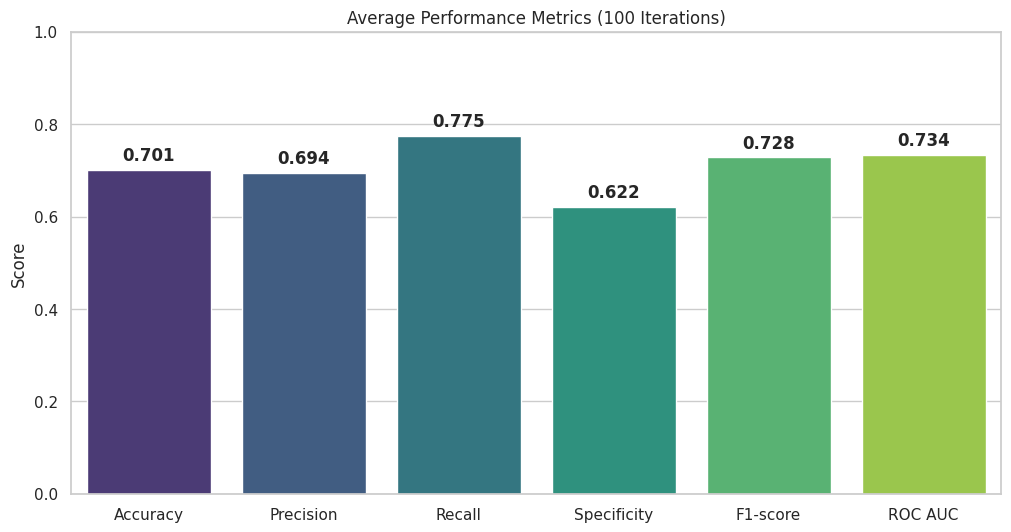

In [ ]:
# Visualization of Average Metrics
plt.figure(figsize=(12, 6))
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'Specificity', 'F1-score', 'ROC AUC']
sns.barplot(x=metrics_to_plot, y=average_metrics[metrics_to_plot].iloc[0], palette='viridis')
plt.title('Average Performance Metrics (100 Iterations)')
plt.ylim(0, 1)
plt.ylabel('Score')
for i, val in enumerate(average_metrics[metrics_to_plot].iloc[0]):
    plt.text(i, val + 0.02, f'{val:.3f}', ha='center', fontweight='bold')
plt.show()